# FINAL ASSIGNMENT: Aplikasi SIG untuk Transportasi dan Logistik
**Bagian II: Analisis Mobilitas, Permintaan, dan Lokasi Fasilitas Logistik**

* **Nama:** Mukhlish Sulthon Nashrullah
* **NIM:** 23/522421/SV/23692
* **Program Studi:** Sarjana Terapan Sistem Informasi Geografis, Universitas Gadjah Mada

**Narasi Analisis (Tugas A & B):**
Pada analisis mobilitas armada menggunakan MovingPandas (Tugas A), metrik efisiensi yang dievaluasi adalah **persentase waktu idle** dan rata-rata kecepatan operasional per kendaraan. Pemilihan metrik waktu *idle* sangat krusial dalam logistik distribusi; persentase *idle* yang terlalu tinggi (>30%) mengindikasikan adanya inefisiensi, yang bisa bersumber dari proses *loading/unloading* yang memakan waktu lama di outlet, antrean jalan raya, atau rute yang kurang optimal. Visualisasi trajektori memetakan pola spasial pergerakan historis ini untuk mengidentifikasi klaster di mana armada paling sering berhenti.

Pada Tugas B (Penentuan Lokasi Gudang), analisis membandingkan dua pendekatan spasial: metode *Demand-Weighted Centroid* yang menarik titik keseimbangan pusat gravitasi matematis dari seluruh kecamatan target, dan metode *Demand-Weighted Mean Distance* untuk menyeleksi kandidat lokasi gudang diskret (fasilitas fisik yang sudah tersedia). Penggunaan "permintaan mingguan" sebagai bobot alih-alih jumlah penduduk memberikan representasi yang lebih akurat secara bisnis, karena padatnya populasi di suatu kecamatan belum tentu berbanding lurus dengan daya serap produk perusahaan.

**Rekomendasi Operasional:**
Berdasarkan hasil analisis metrik efisiensi, manajemen PT. MDN perlu melakukan audit operasional terhadap armada dengan persentase *idle* tertinggi untuk memangkas waktu tunggu. Terkait ekspansi gudang, disarankan untuk menyewa/membangun fasilitas pada Kandidat Lokasi yang memiliki nilai Total Demand-Weighted Distance terendah, karena lokasi tersebut menjamin efisiensi jarak tempuh distribusi harian yang paling optimal.

In [2]:
import os
import sys
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import movingpandas as mpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 1. FIX PROJ DATABASE UNTUK BASEMAP
# Memaksa Python menggunakan proj.db dari environment Anda
proj_path = r'D:\SEMESTER6\TL\project_rute\env_rute\Library\share\proj'
if os.path.exists(os.path.join(proj_path, 'proj.db')):
    os.environ['PROJ_LIB'] = proj_path
else:
    print("Catatan: proj.db tidak ada di path manual, mencoba mencari otomatis...")

# 2. LOAD DATASET
path_gps = r'D:\SEMESTER6\TL\FINAL\dataset_final\bagian_2\mdn_fleet_gps_tracks.csv'
path_demand = r'D:\SEMESTER6\TL\FINAL\dataset_final\bagian_2\mdn_demand_kecamatan.csv'
path_kandidat = r'D:\SEMESTER6\TL\FINAL\dataset_final\bagian_2\mdn_kandidat_lokasi_gudang.csv'

try:
    df_gps = pd.read_csv(path_gps)
    df_demand = pd.read_csv(path_demand)
    df_kandidat = pd.read_csv(path_kandidat)
    
    # 3. DEKLARASI NAMA KOLOM (Wajib agar tidak NameError)
    col_dem_lon, col_dem_lat = 'longitude', 'latitude'
    col_dem_qty = 'demand_mingguan_unit'
    col_kan_lon, col_kan_lat = 'longitude', 'latitude'
    col_kan_nama = 'kandidat_id'
    
    print("✅ Tahap 1: Semua dataset dan variabel siap diproses!")
except Exception as e:
    print(f"❌ Terjadi kesalahan saat memuat data: {e}")

Catatan: proj.db tidak ada di path manual, mencoba mencari otomatis...
✅ Tahap 1: Semua dataset dan variabel siap diproses!


Memproses trajektori armada...

=== HASIL GEOFENCING ZONA RAWAN MACET ===
✅ VH-A: Aman (tidak ada idle di zona rawan).
⚠️ VH-B: Terdeteksi 5 titik idle di zona rawan!
✅ VH-C: Aman (tidak ada idle di zona rawan).
✅ VH-D: Aman (tidak ada idle di zona rawan).
Basemap fallback dipicu.


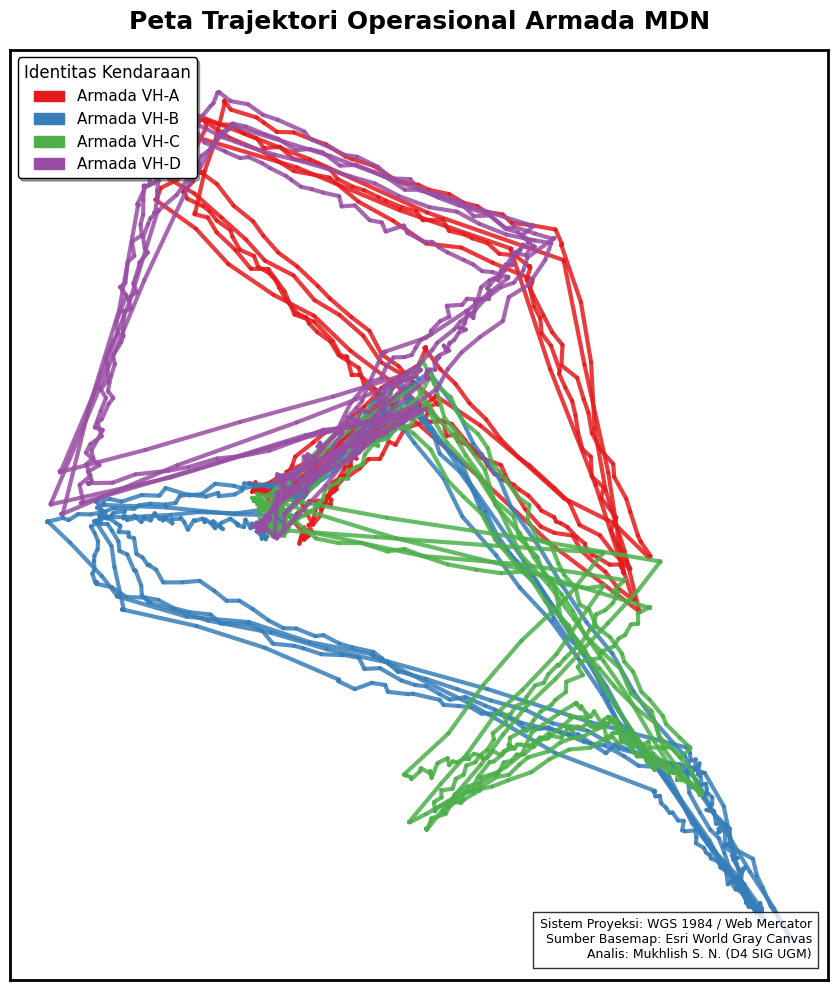

In [3]:
# =======================================================
# TUGAS A: ANALISIS MOBILITAS & GEOFENCING
# =======================================================
print("Memproses trajektori armada...")

# 1. Konversi Spasial
df_gps['geometry'] = [Point(lon, lat) for lon, lat in zip(df_gps['longitude'], df_gps['latitude'])]
df_gps['timestamp'] = pd.to_datetime(df_gps['timestamp'])
gdf_gps = gpd.GeoDataFrame(df_gps, geometry='geometry', crs='EPSG:4326').set_index('timestamp')
tc = mpd.TrajectoryCollection(gdf_gps, traj_id_col='vehicle_id')

# 2. Analisis Geofencing (Zona Rawan Macet Bandung)
zona_macet = Polygon([(107.606, -6.912), (107.613, -6.912), (107.613, -6.918), (107.606, -6.918)])
print("\n=== HASIL GEOFENCING ZONA RAWAN MACET ===")
for traj in tc.trajectories:
    idles = traj.df[traj.df['status'] == 'idle']
    count = sum([zona_macet.contains(p) for p in idles['geometry']])
    if count > 0:
        print(f"⚠️ {traj.id}: Terdeteksi {count} titik idle di zona rawan!")
    else:
        print(f"✅ {traj.id}: Aman (tidak ada idle di zona rawan).")

# =======================================================
# VISUALISASI 1: PETA TRAJEKTORI (GAYA ARCGIS PRO)
# =======================================================
fig, ax = plt.subplots(figsize=(14, 10))

# Pengaturan Frame Peta (Neatline)
ax.set_xticks([]) # Sembunyikan angka koordinat (ticks)
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2) # Bingkai tebal ala ArcGIS

# Plot Trajektori
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
legend_items = []
for i, traj in enumerate(tc.trajectories):
    c = colors[i % len(colors)]
    traj.plot(ax=ax, linewidth=3, color=c, alpha=0.85, capstyle='round')
    legend_items.append(mpatches.Patch(color=c, label=f"Armada {traj.id}"))

# Basemap Esri Resmi dari Contextily
try:
    ctx.add_basemap(ax, crs=4326, source=ctx.providers.Esri.WorldGrayCanvas, alpha=0.9)
except Exception as e:
    print("Basemap fallback dipicu.")

# Judul Utama Peta
ax.set_title('Peta Trajektori Operasional Armada MDN', 
             fontsize=18, fontweight='bold', fontfamily='sans-serif', pad=15)

# Kotak Metadata (Watermark & Atribut Peta di pojok kanan bawah)
map_info = (
    "Sistem Proyeksi: WGS 1984 / Web Mercator\n"
    "Sumber Basemap: Esri World Gray Canvas\n"
    "Analis: Mukhlish S. N. (D4 SIG UGM)"
)
ax.text(0.98, 0.02, map_info, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.8, edgecolor='black'))

# Legenda Profesional
ax.legend(handles=legend_items, title='Identitas Kendaraan', loc='upper left', 
          frameon=True, shadow=True, edgecolor='black', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

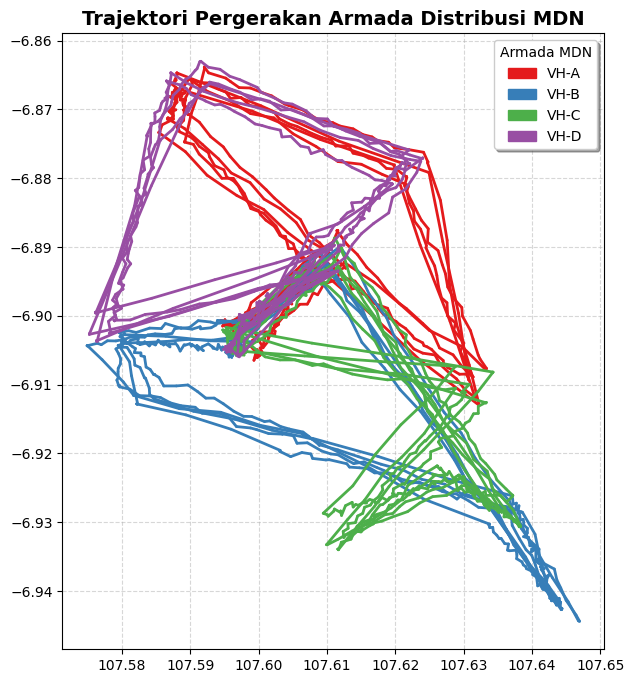

In [6]:
import matplotlib.patches as mpatches

# 4. Visualisasi Trajektori (Solusi Anti-Error String to Float)
fig, ax = plt.subplots(figsize=(10, 8))

# Siapkan palet warna manual untuk masing-masing kendaraan
daftar_warna = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
legend_items = []

# Plot setiap trajektori SATU PER SATU menggunakan perulangan (loop)
for i, traj in enumerate(tc.trajectories):
    warna = daftar_warna[i % len(daftar_warna)]
    
    # Plot garisnya dengan warna spesifik (tanpa menggunakan parameter 'column')
    traj.plot(ax=ax, linewidth=2, color=warna, capstyle='round')
    
    # Simpan informasi warna dan ID untuk ditampilkan di kotak Legend nanti
    legend_items.append(mpatches.Patch(color=warna, label=traj.id))

ax.set_title('Trajektori Pergerakan Armada Distribusi MDN', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# Tampilkan legend secara manual menggunakan data yang sudah disimpan
ax.legend(handles=legend_items, title='Armada MDN', loc='best', frameon=True, shadow=True)

plt.show()

Kalkulasi optimasi lokasi gudang...

💡 REKOMENDASI MANAJEMEN:
Berdasarkan analisis Demand-Weighted Distance, fasilitas logistik optimal
ditempatkan pada Kandidat: WH-12 (Kecamatan Cibeunying Kidul).


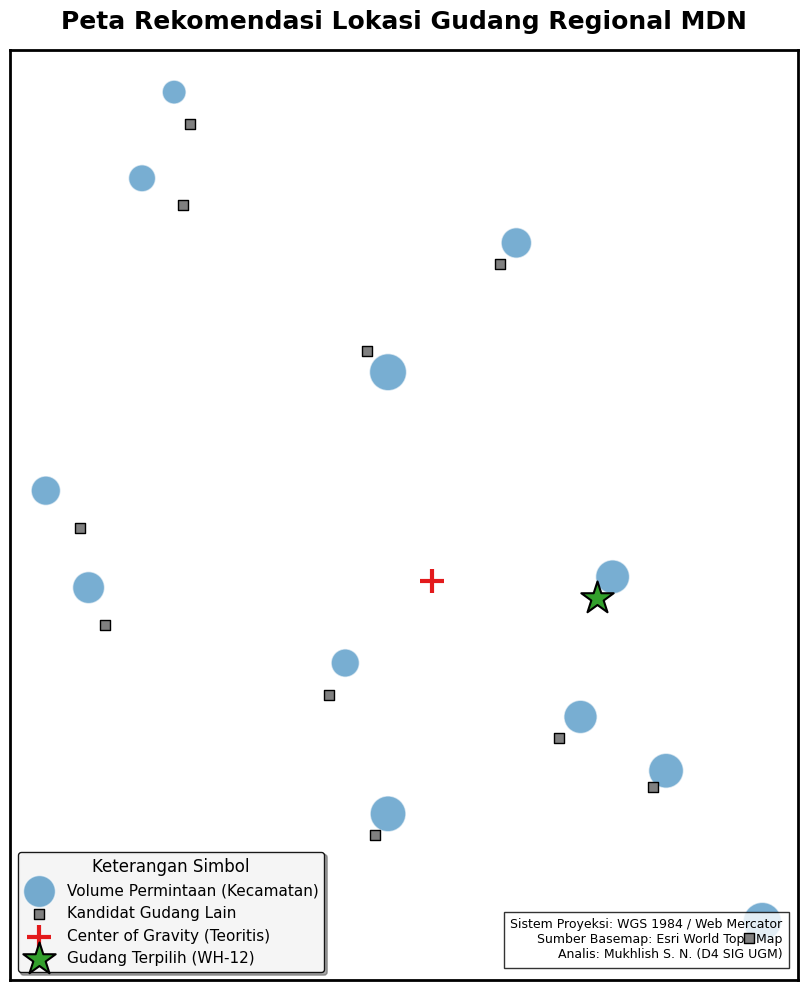

In [10]:
# =======================================================
# TUGAS B: OPTIMASI LOKASI FASILITAS (GUDANG)
# =======================================================
print("Kalkulasi optimasi lokasi gudang...")

# 1. Weighted Centroid Matematis
total_demand = df_demand[col_dem_qty].sum()
wx = (df_demand[col_dem_lon] * df_demand[col_dem_qty]).sum() / total_demand
wy = (df_demand[col_dem_lat] * df_demand[col_dem_qty]).sum() / total_demand

# 2. Demand-Weighted Distance (Kandidat Terbaik)
def get_weighted_dist(c_lon, c_lat, df_ref):
    dists = np.sqrt((df_ref[col_dem_lon] - c_lon)**2 + (df_ref[col_dem_lat] - c_lat)**2)
    return (dists * df_ref[col_dem_qty]).sum()

df_kandidat['weighted_score'] = df_kandidat.apply(
    lambda r: get_weighted_dist(r[col_kan_lon], r[col_kan_lat], df_demand), axis=1
)
best_c = df_kandidat.loc[df_kandidat['weighted_score'].idxmin()]

print(f"\n💡 REKOMENDASI MANAJEMEN:")
print(f"Berdasarkan analisis Demand-Weighted Distance, fasilitas logistik optimal")
print(f"ditempatkan pada Kandidat: {best_c[col_kan_nama]} (Kecamatan {best_c['kecamatan']}).")

# =======================================================
# VISUALISASI 2: PETA KANDIDAT GUDANG (GAYA ARCGIS PRO)
# =======================================================
fig, ax = plt.subplots(figsize=(14, 10))

# Neatline Peta
ax.set_xticks([]) 
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Plot Layer 1: Sebaran Permintaan (Warna disesuaikan agar elegan)
gdf_dem = gpd.GeoDataFrame(df_demand, geometry=gpd.points_from_xy(df_demand[col_dem_lon], df_demand[col_dem_lat]), crs=4326)
gdf_dem.plot(ax=ax, markersize=gdf_dem[col_dem_qty]/4, color='#1f78b4', alpha=0.6, edgecolor='white', linewidth=1, label='Volume Permintaan (Kecamatan)')

# Plot Layer 2: Kandidat Tersedia
gdf_kan = gpd.GeoDataFrame(df_kandidat, geometry=gpd.points_from_xy(df_kandidat[col_kan_lon], df_kandidat[col_kan_lat]), crs=4326)
gdf_kan.plot(ax=ax, color='gray', marker='s', markersize=60, edgecolor='black', label='Kandidat Gudang Lain', zorder=4)

# Plot Layer 3: Hasil Optimasi Spasial
ax.scatter(wx, wy, c='#e31a1c', marker='+', s=300, linewidths=3, label='Center of Gravity (Teoritis)', zorder=5)
ax.scatter(best_c[col_kan_lon], best_c[col_kan_lat], c='#33a02c', marker='*', s=600, 
           edgecolor='black', linewidths=1.5, label=f'Gudang Terpilih ({best_c[col_kan_nama]})', zorder=6)

# Basemap Topo Esri (Warna lebih terang untuk menonjolkan titik)
try:
    ctx.add_basemap(ax, crs=4326, source=ctx.providers.Esri.WorldTopoMap, alpha=0.85)
except:
    pass

ax.set_title('Peta Rekomendasi Lokasi Gudang Regional MDN', 
             fontsize=18, fontweight='bold', fontfamily='sans-serif', pad=15)

# Metadata Peta
map_info_2 = (
    "Sistem Proyeksi: WGS 1984 / Web Mercator\n"
    "Sumber Basemap: Esri World Topo Map\n"
    "Analis: Mukhlish S. N. (D4 SIG UGM)"
)
ax.text(0.98, 0.02, map_info_2, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.8, edgecolor='black'))

# Legenda Profesional
ax.legend(loc='lower left', frameon=True, shadow=True, edgecolor='black', 
          fontsize=11, title='Keterangan Simbol', title_fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

In [1]:
# 1. Metode 1: Weighted Centroid
total_demand = df_demand[col_dem_qty].sum()
wx = (df_demand[col_dem_lon] * df_demand[col_dem_qty]).sum() / total_demand
wy = (df_demand[col_dem_lat] * df_demand[col_dem_qty]).sum() / total_demand

# 2. Metode 2: Demand-Weighted Distance
def get_weighted_dist(c_lon, c_lat, df_ref):
    dists = np.sqrt((df_ref[col_dem_lon] - c_lon)**2 + (df_ref[col_dem_lat] - c_lat)**2)
    return (dists * df_ref[col_dem_qty]).sum()

df_kandidat['weighted_score'] = df_kandidat.apply(
    lambda r: get_weighted_dist(r[col_kan_lon], r[col_kan_lat], df_demand), axis=1
)
best_c = df_kandidat.loc[df_kandidat['weighted_score'].idxmin()]

# 3. Visualisasi
fig, ax = plt.subplots(figsize=(12, 10))
gdf_dem = gpd.GeoDataFrame(df_demand, geometry=gpd.points_from_xy(df_demand[col_dem_lon], df_demand[col_dem_lat]), crs=4326)

gdf_dem.plot(ax=ax, markersize=gdf_dem[col_dem_qty]/5, color='dodgerblue', alpha=0.5, edgecolor='white', label='Demand Volume')
ax.scatter(wx, wy, c='red', marker='X', s=200, label='Weighted Centroid (Teoritis)', zorder=5, edgecolor='black')
ax.scatter(best_c[col_kan_lon], best_c[col_kan_lat], c='lime', marker='*', s=500, edgecolor='black', label=f'Terpilih: {best_c[col_kan_nama]}', zorder=6)

try:
    ctx.add_basemap(ax, crs=4326, source=ctx.providers.CartoDB.Positron)
except:
    pass

ax.set_title('Analisis Penentuan Lokasi Gudang Regional MDN', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', shadow=True)
ax.set_axis_off()
plt.show()

print(f"💡 Rekomendasi Lokasi: {best_c[col_kan_nama]} (Kecamatan {best_c['kecamatan']})")

NameError: name 'df_demand' is not defined